# Previsão: SLE (1 item) e Monte Carlo (N itens)

Notebook *companion* dos slides da talk **"Quando vai ficar pronto?"**.

Ideia central (igual slides): previsão = **dados históricos** + **probabilidade**.

O que você consegue aqui:
- **SLE (Service Level Expectation)**: em quantos dias terminamos **1 item** com X% de confiança.
- **Simulação Monte Carlo**: em quantos dias terminamos **N itens** com X% de confiança.

Regras (decisões deste notebook):
- Input mínimo: CSV com `started_at` e `finished_at`.
- Se vier datetime, **ignora hora** (normaliza para data).
- Throughput **sempre por dia** (inclui fins de semana + zeros no intervalo).

In [1]:
import sys
from pathlib import Path

# Garante import do helper `notebook/flow_forecast.py` independente do cwd.
# Evita `import notebook...` (conflita com pacote do Jupyter).
repo_root = Path.cwd()
helper_dir = repo_root / "notebook"
if helper_dir.exists():
    sys.path.insert(0, str(helper_dir))
else:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from flow_forecast import (
    cycle_time_days_values,
    daily_throughput,
    monte_carlo_days_to_finish,
    monte_carlo_items_in_days,
    percentiles_from_sim,
    read_items_csv,
    sle_days,
)

## Dados de entrada

Nos slides, a premissa é: você só precisa coletar duas coisas por item:
- data de início (`started_at`)
- data de fim (`finished_at`)

A partir disso, derivamos:
- **Lead time / cycle time (em dias)** de cada item
- **Throughput diário** (quantos itens terminaram por dia)


In [2]:
# Ajusta aqui
CSV_PATH = Path("exemplo.csv")

# Nível de confiança (ex.: 0.85 = 85%)
CONFIDENCE = 0.85

# Monte Carlo
N_ITEMS = 50
N_DAYS = 30
RUNS = 10_000
SEED = 42

In [3]:
df = read_items_csv(CSV_PATH)
df.head()

,started_at,finished_at
1,2026-03-03,2026-03-03
2,2026-03-03,2026-03-06
3,2026-03-04,2026-03-08
4,2026-03-05,2026-03-09
5,2026-03-06,2026-03-11


In [4]:
print(f"rows={len(df)}")
print(f"started_at:  {df['started_at'].min().date()} → {df['started_at'].max().date()}")
print(f"finished_at: {df['finished_at'].min().date()} → {df['finished_at'].max().date()}")

rows=56
started_at:  2026-03-03 → 2026-04-12
finished_at: 2026-03-03 → 2026-04-20


## Previsão de 1 item: percentis e SLE

Nos slides, a ideia é que nosso trabalho tem **cauda longa**: é mais fácil aparecer algo que atrase do que algo que adiante.

Então, em vez de média, usamos **percentis** do lead time histórico.

- Ex.: **P85 = 11 dias** significa: *85% dos itens terminam em 11 dias ou menos*.
- O **SLE** é esse compromisso probabilístico: *"nosso SLE atual é X dias @ Y%"*.

In [5]:
ct = cycle_time_days_values(df)
pcts = {
    50: int(np.percentile(ct, 50)),
    85: int(np.percentile(ct, 85)),
    95: int(np.percentile(ct, 95)),
}
sle = sle_days(ct, confidence=CONFIDENCE)

print(f"P50={pcts[50]} dias  P85={pcts[85]} dias  P95={pcts[95]} dias")
print(f"SLE = {sle} dias @ {int(CONFIDENCE*100)}%")

P50=6 dias  P85=8 dias  P95=8 dias
SLE = 8 dias @ 85%


## Previsão de N itens: throughput diário

Para vários itens, a base deixa de ser o lead time individual e passa a ser o **throughput**.

Aqui, throughput é **quantos itens terminaram por dia**. Incluímos explicitamente dias com 0 entregas (inclusive fins de semana).

In [6]:
tp = daily_throughput(df)
print(f"dias no histórico={len(tp)}")
print(f"média={tp.mean():.2f} itens/dia")
print(f"min={tp.min()}  max={tp.max()}")
print(f"% dias zero={float((tp==0).mean()*100):.1f}%")

dias no histórico=49
média=1.14 itens/dia
min=0  max=3
% dias zero=18.4%


## Simulação Monte Carlo: quando entregamos N itens?

O que a simulação faz (igual slides):

- Você tem um histórico de throughput diário: `[1, 0, 1, 3, 2, 0, ...]`
- Para simular a entrega de `N_ITEMS`, você vai **sorteando** um valor por dia desse histórico e acumulando até concluir.
- Repete isso `RUNS` vezes e olha percentis (P50, P85, P95) dos resultados.

In [7]:
sim = monte_carlo_days_to_finish(N_ITEMS, tp, runs=RUNS, seed=SEED)
out = percentiles_from_sim(sim, ps=(50, 85, 95))

print(f"runs={RUNS}  n_items={N_ITEMS}")
print(f"P50={out[50]:.0f} dias  P85={out[85]:.0f} dias  P95={out[95]:.0f} dias")

runs=10000  n_items=50
P50=44 dias  P85=49 dias  P95=52 dias


### Interpretando resultado

- **P85** costuma ser bom default para comunicar externamente: erro ~15% por definição.
- P50 erra metade das vezes.
- P95 é mais conservador.


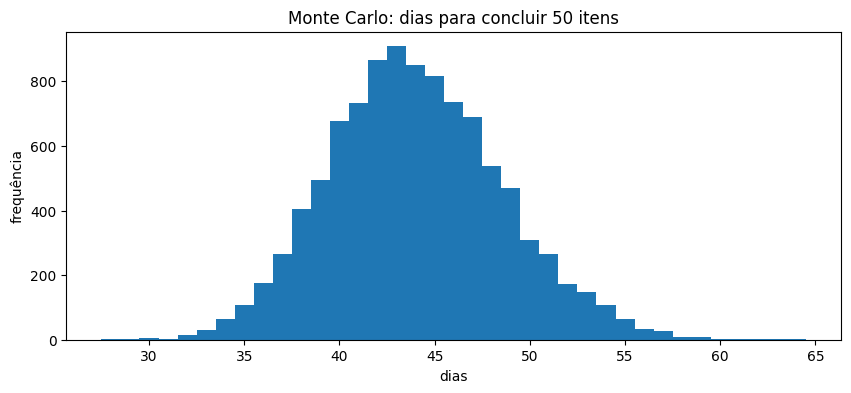

In [8]:
plt.figure(figsize=(10, 4))
bins = range(int(sim.min()), int(sim.max()) + 2)
plt.hist(sim, bins=bins, align="left")
plt.title(f"Monte Carlo: dias para concluir {N_ITEMS} itens")
plt.xlabel("dias")
plt.ylabel("frequência")
plt.show()

## Simulação Monte Carlo: quantos itens cabem em N dias?

Outra pergunta comum (também aparece nos slides):

- Dado um prazo fixo de `N_DAYS`, **quantos itens** conseguimos entregar?

A mecânica é igual: em cada simulação, sorteamos `N_DAYS` valores de throughput do histórico e somamos.

In [9]:
sim_items = monte_carlo_items_in_days(N_DAYS, tp, runs=RUNS, seed=SEED)
out_items = percentiles_from_sim(sim_items, ps=(50, 85, 95))

print(f"runs={RUNS}  n_days={N_DAYS}")
print(f"P50={out_items[50]:.0f} itens  P85={out_items[85]:.0f} itens  P95={out_items[95]:.0f} itens")

runs=10000  n_days=30
P50=34 itens  P85=39 itens  P95=41 itens


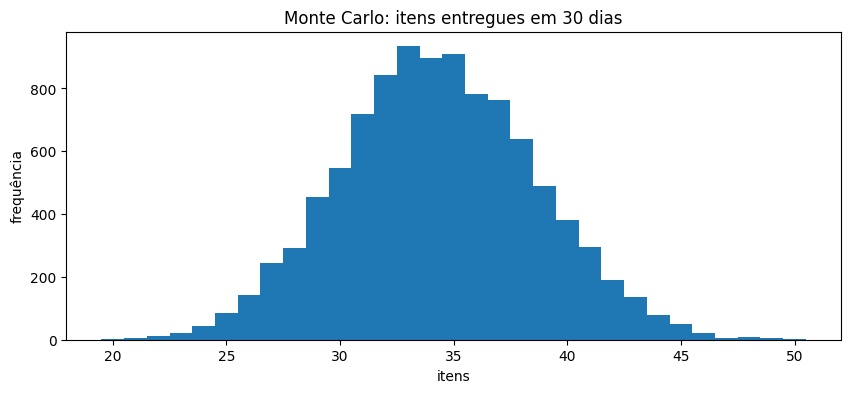

In [10]:
plt.figure(figsize=(10, 4))
bins = range(int(sim_items.min()), int(sim_items.max()) + 2)
plt.hist(sim_items, bins=bins, align="left")
plt.title(f"Monte Carlo: itens entregues em {N_DAYS} dias")
plt.xlabel("itens")
plt.ylabel("frequência")
plt.show()